In [1]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Consistent style for matplotlib charts
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 150, 'figure.figsize': (12, 5)})

# Output directories
PROCESSED = Path("/data/processed")
CHARTS    = Path("/reports/charts")
CHARTS.mkdir(parents=True, exist_ok=True)
print("Directories ready.")

Directories ready.


In [2]:
# Cell 2 — Load all cleaned datasets
nav         = pd.read_csv("data/processed/clean_nav.csv",           parse_dates=["date"])
aum         = pd.read_csv("data/processed/clean_aum.csv")
sip         = pd.read_csv("data/processed/clean_sip_inflows.csv")
cat_inflows = pd.read_csv("data/processed/clean_category_inflows.csv")
folios      = pd.read_csv("data/processed/clean_folio_count.csv")
perf        = pd.read_csv("data/processed/clean_schema_performance.csv")
txns        = pd.read_csv("data/processed/clean_transactions.csv",  parse_dates=["transaction_date"])
holdings    = pd.read_csv("data/processed/clean_portfolio_holdings.csv")
funds       = pd.read_csv("data/processed/clean_fund_master.csv")
benchmark   = pd.read_csv("data/processed/clean_benchmark_indices.csv", parse_dates=["date"])

# Quick sanity check
for name, df in [("nav", nav), ("aum", aum), ("sip", sip), ("txns", txns)]:
    print(f"{name}: {df.shape}")

nav: (46000, 4)
aum: (90, 5)
sip: (48, 6)
txns: (32778, 13)


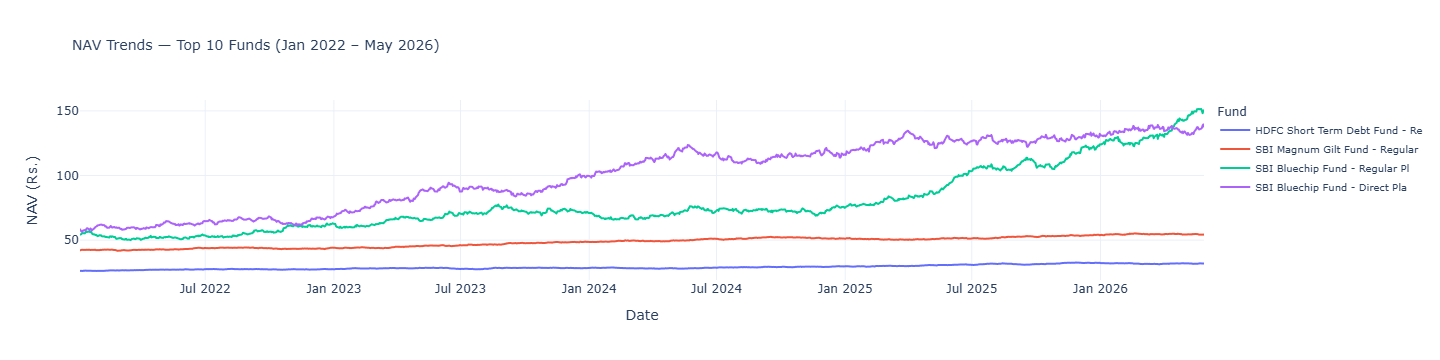

✓ Saved nav_trend_lines.html


In [3]:
# Cell 3 — NAV Trend Lines (Plotly interactive)
# Pick 10 representative funds to keep the chart readable
top10_codes = funds.groupby("category").head(2)["amfi_code"].tolist()[:10]
nav10 = nav[nav["amfi_code"].isin(top10_codes)].copy()

# Merge scheme_name for legend labels
nav10 = nav10.merge(funds[["amfi_code", "scheme_name"]], on="amfi_code", how="left")
nav10["scheme_short"] = nav10["scheme_name"].str[:30]  # truncate long names

fig = px.line(
    nav10,
    x="date",
    y="nav",
    color="scheme_short",
    title="NAV Trends — Top 10 Funds (Jan 2022 – May 2026)",
    labels={"nav": "NAV (Rs.)", "date": "Date", "scheme_short": "Fund"},
    template="plotly_white",
)
fig.update_layout(
    legend=dict(font=dict(size=10), orientation="v", x=1.01),
    title_font_size=14,
    hovermode="x unified",
)
fig.write_html(str(CHARTS / "nav_trend_lines.html"))
fig.show()
print("✓ Saved nav_trend_lines.html")

In [4]:
# Cell 4 — AUM Growth Grouped Bar Chart
# Expected columns: fund_house, year, aum_crore  (or similar — adjust if needed)
print(aum.columns.tolist())   # check first
print(aum.head(3))

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']
         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195


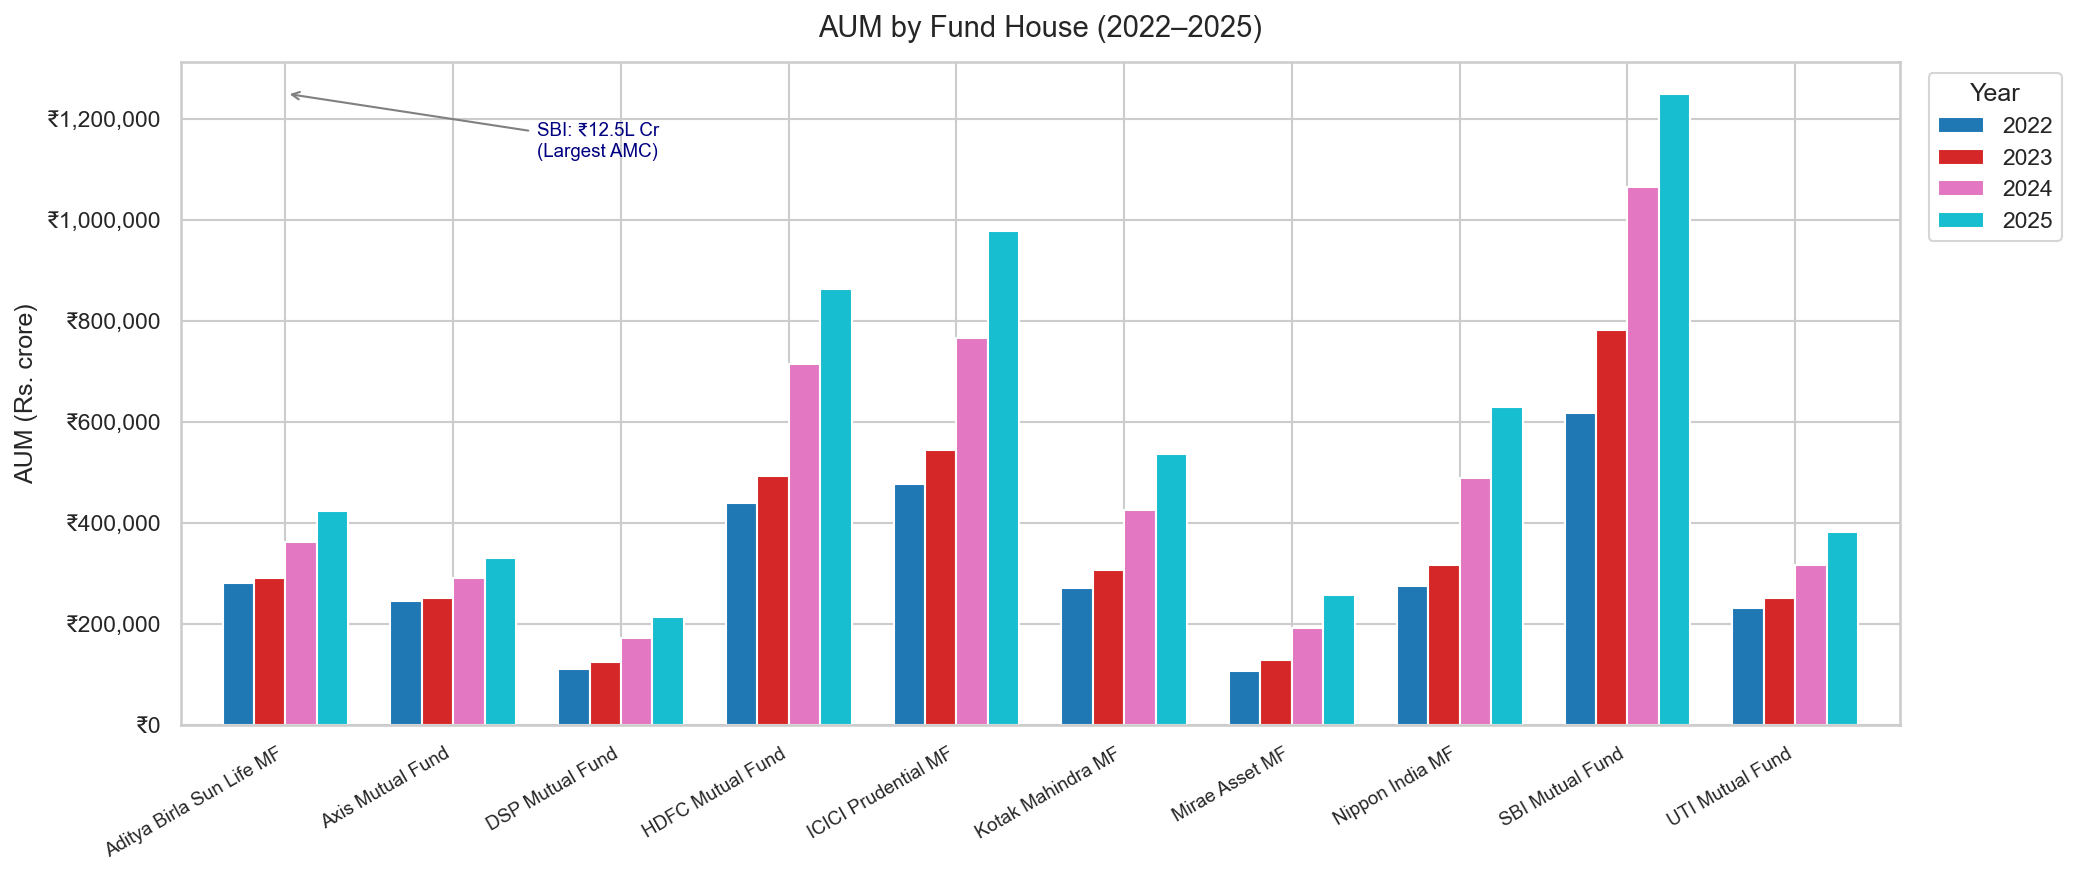

✓ Saved aum_growth_by_amc.png


In [5]:
# Cell 5 — Plot
fig, ax = plt.subplots(figsize=(14, 6))

# Pivot so years become columns
aum["date"] = pd.to_datetime(aum["date"])
aum["year"] = aum["date"].dt.year
aum_pivot = aum.pivot_table(index="fund_house", columns="year", values="aum_crore")

aum_pivot.plot(
    kind="bar",
    ax=ax,
    width=0.75,
    colormap="tab10",
)

ax.set_title("AUM by Fund House (2022–2025)", fontsize=14, pad=12)
ax.set_xlabel("")
ax.set_ylabel("AUM (Rs. crore)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₹{x:,.0f}"))
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=9)
ax.legend(title="Year", bbox_to_anchor=(1.01, 1), loc="upper left")

# Annotate SBI bar for Dec 2025
# SBI AUM ~12,50,000 crore = 12.5 lakh crore
ax.annotate("SBI: ₹12.5L Cr\n(Largest AMC)",
            xy=(0, aum_pivot.loc["SBI Mutual Fund", 2025] if "SBI Mutual Fund" in aum_pivot.index else 0),
            xytext=(1.5, aum_pivot.max().max() * 0.9),
            arrowprops=dict(arrowstyle="->", color="gray"),
            fontsize=9, color="navy")

plt.tight_layout()
plt.savefig(CHARTS / "aum_growth_by_amc.png", bbox_inches="tight")
plt.show()
print("✓ Saved aum_growth_by_amc.png")

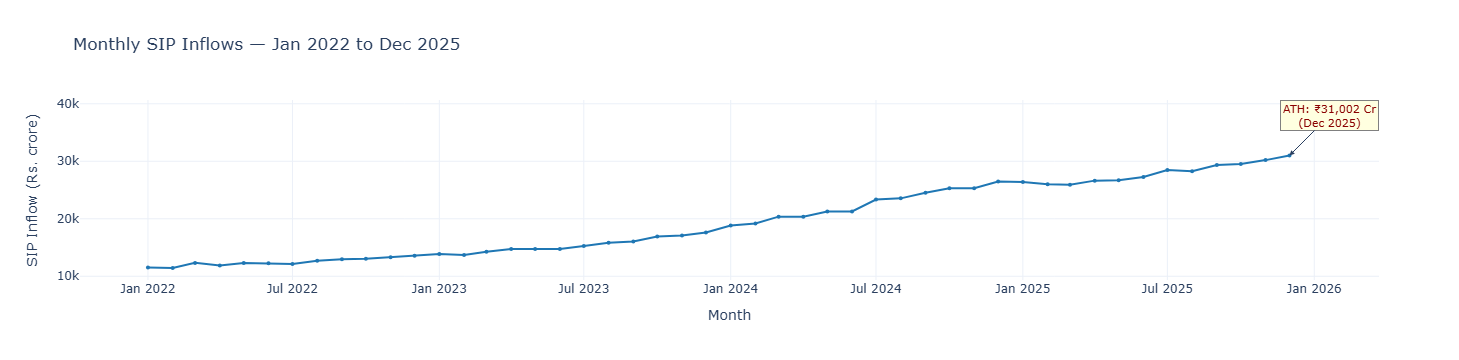

✓ Saved sip_inflow_trend.html


In [9]:
# Cell 6 — SIP Inflows Monthly
# Expected columns: month (YYYY-MM), sip_inflow_crore
sip["month_dt"] = pd.to_datetime(sip["month"])
sip_sorted = sip.sort_values("month_dt")

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=sip_sorted["month_dt"],
    y=sip_sorted["sip_inflow_crore"],
    mode="lines+markers",
    line=dict(color="#1f77b4", width=2),
    marker=dict(size=4),
    name="SIP Inflow",
))

# Mark the all-time high milestone
ath_row = sip_sorted.loc[sip_sorted["sip_inflow_crore"].idxmax()]
fig.add_annotation(
    x=ath_row["month_dt"],
    y=ath_row["sip_inflow_crore"],
    text=f"ATH: ₹{ath_row['sip_inflow_crore']:,.0f} Cr<br>(Dec 2025)",
    showarrow=True,
    arrowhead=2,
    ax=40,
    ay=-40,
    font=dict(size=11, color="darkred"),
    bgcolor="lightyellow",
    bordercolor="gray",
)

fig.update_layout(
    title="Monthly SIP Inflows — Jan 2022 to Dec 2025",
    xaxis_title="Month",
    yaxis_title="SIP Inflow (Rs. crore)",
    template="plotly_white",
    hovermode="x",
)
fig.write_html(str(CHARTS / "sip_inflow_trend.html"))
fig.show()
print("✓ Saved sip_inflow_trend.html")

In [10]:
# Cell 7 — Category Inflows Heatmap
# Expected columns: month, category, net_inflow_crore (adjust as needed)
print(cat_inflows.columns.tolist())
print(cat_inflows.head(3))

['month', 'category', 'net_inflow_crore']
     month   category  net_inflow_crore
0  2024-04  Large Cap            2413.0
1  2024-04    Mid Cap            3897.0
2  2024-04  Small Cap            3533.0


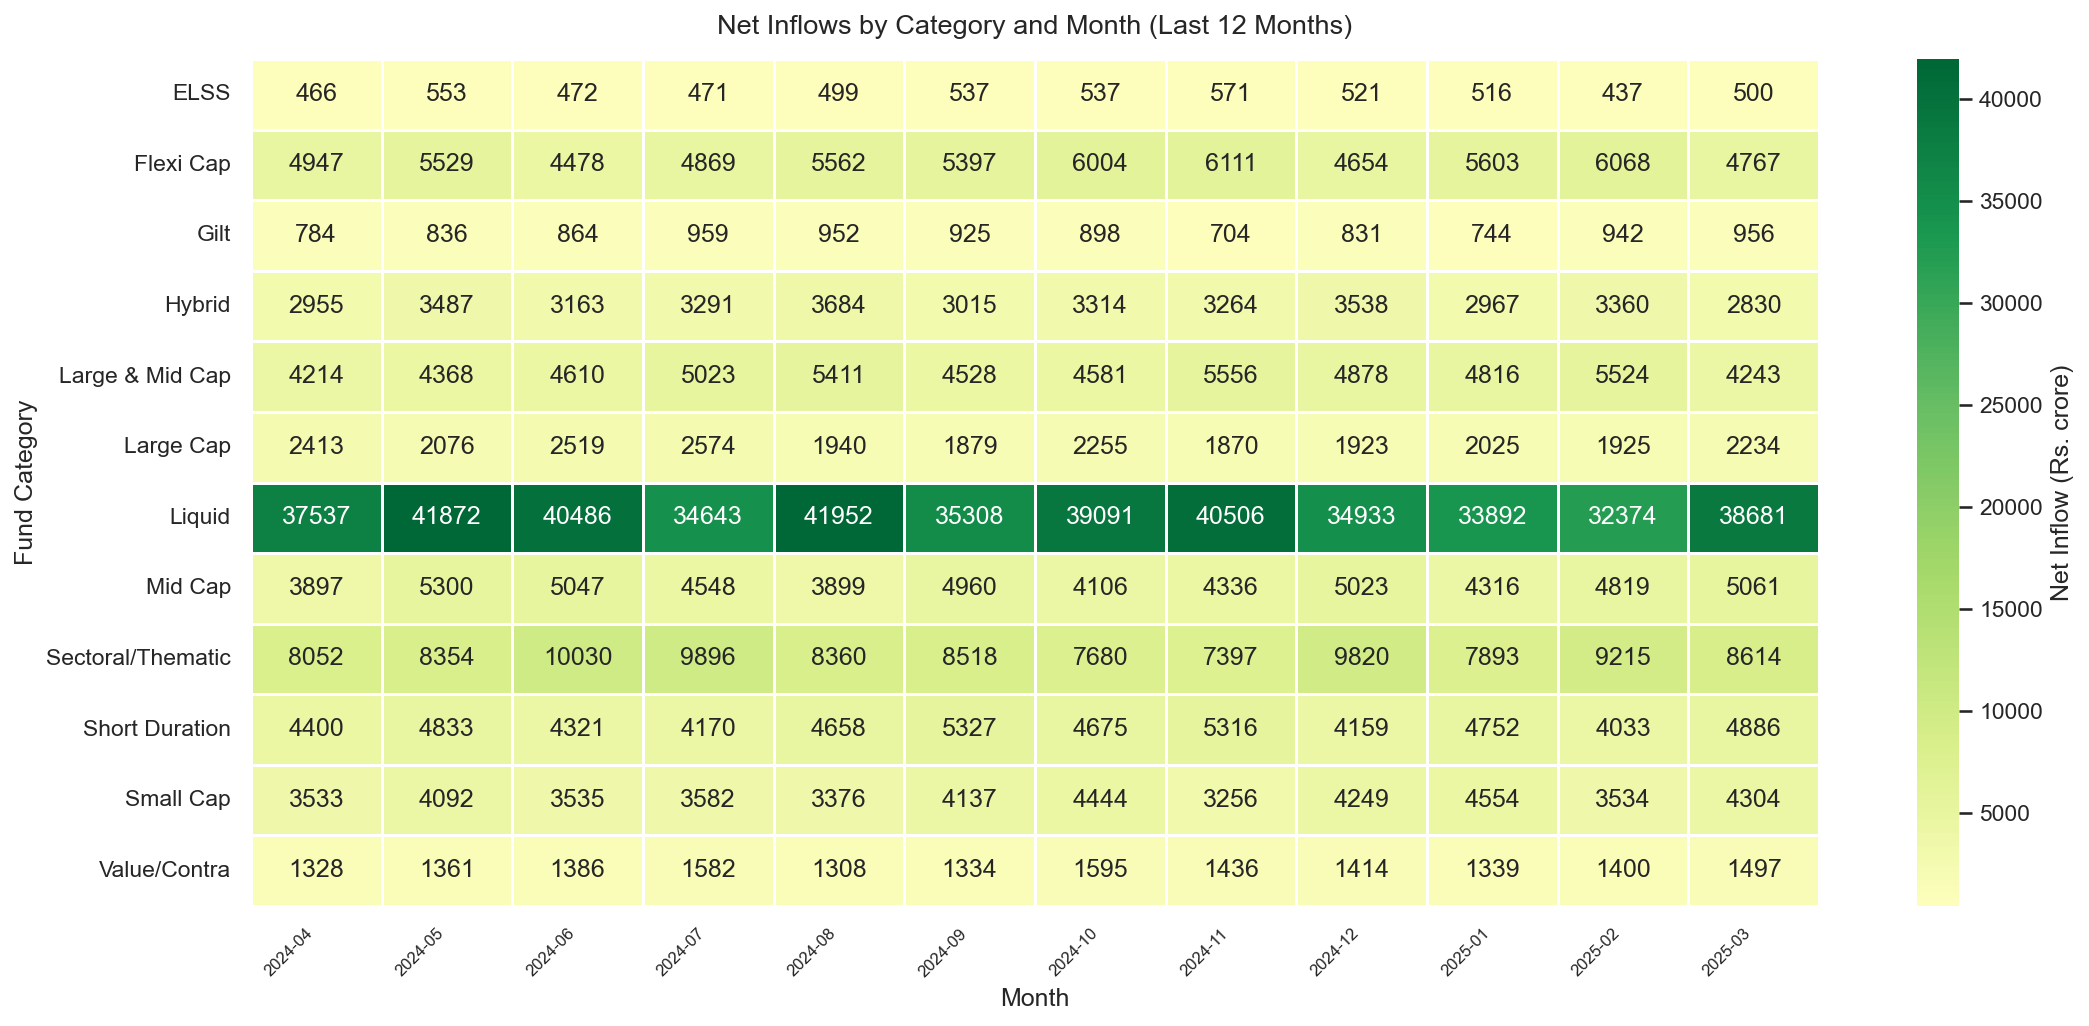

✓ Saved category_inflow_heatmap.png


In [11]:
# Cell 8 — Heatmap
pivot_cat = cat_inflows.pivot_table(
    index="category",
    columns="month",       # YYYY-MM strings
    values="net_inflow_crore",
    aggfunc="sum"
)

# Keep last 12 months for readability
pivot_cat = pivot_cat[sorted(pivot_cat.columns)[-12:]]

fig, ax = plt.subplots(figsize=(15, 7))
sns.heatmap(
    pivot_cat,
    cmap="RdYlGn",         # red = outflow, green = inflow
    center=0,
    annot=True,
    fmt=".0f",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Net Inflow (Rs. crore)"},
)
ax.set_title("Net Inflows by Category and Month (Last 12 Months)", fontsize=13, pad=12)
ax.set_xlabel("Month")
ax.set_ylabel("Fund Category")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)

plt.tight_layout()
plt.savefig(CHARTS / "category_inflow_heatmap.png", bbox_inches="tight")
plt.show()
print("✓ Saved category_inflow_heatmap.png")

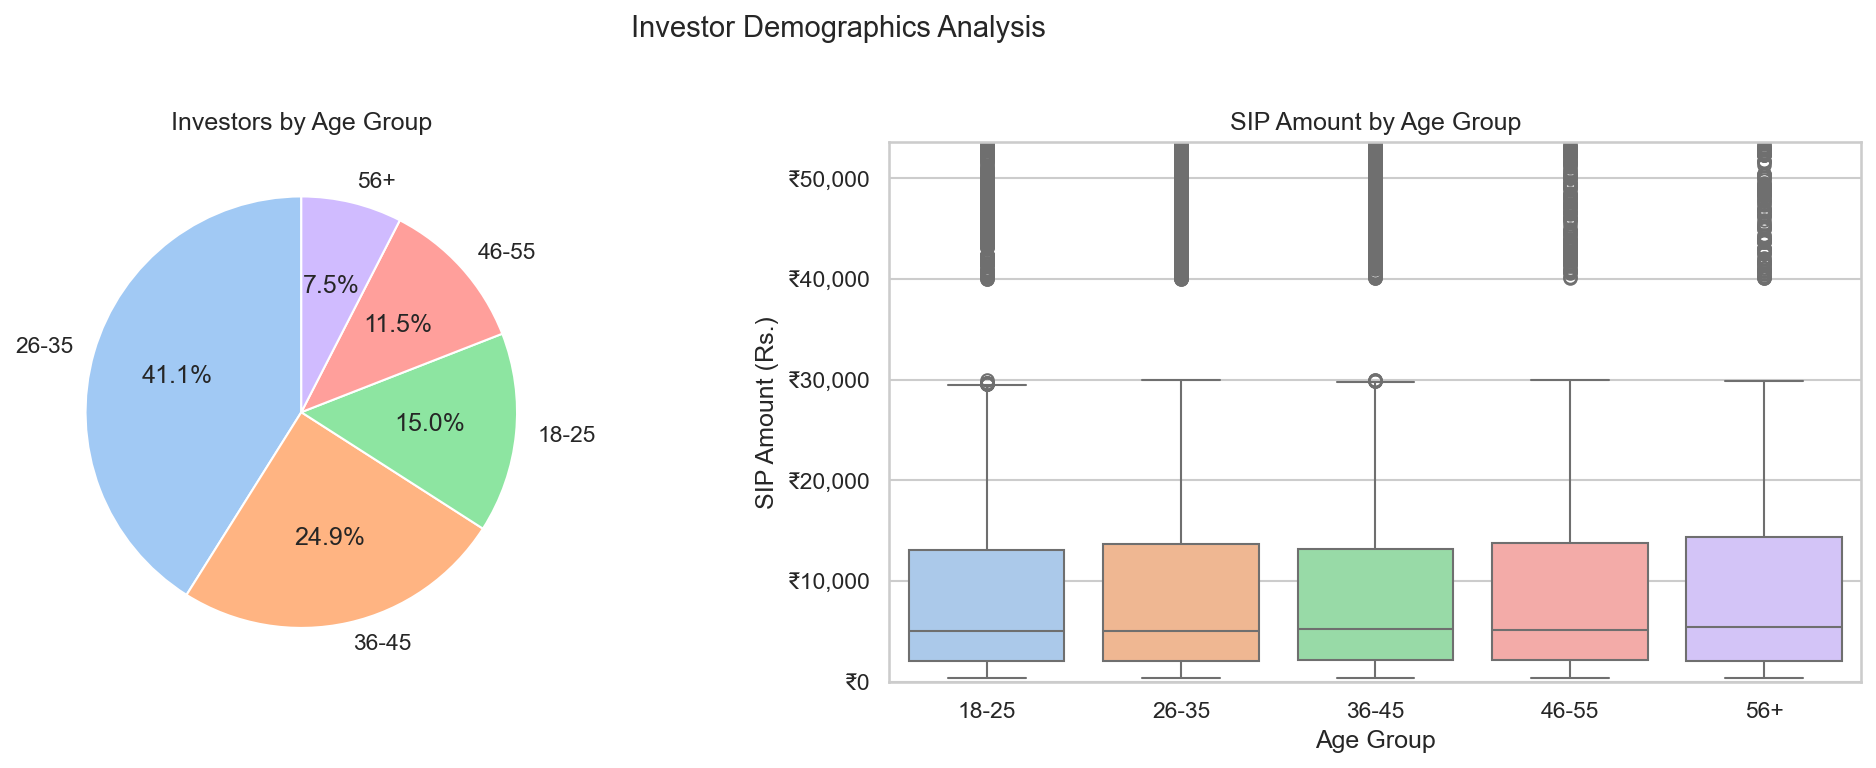

✓ Saved investor_demographics.png


In [14]:
# Cell 9 — Age Group Distribution (Pie)
age_counts = txns["age_group"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
axes[0].pie(
    age_counts.values,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("pastel"),
)
axes[0].set_title("Investors by Age Group")

# Boxplot — SIP amount by age group
sip_txns = txns[txns["transaction_type"] == "Sip"]
order = ["18-25", "26-35", "36-45", "46-55", "56+"]

sns.boxplot(
    data=sip_txns,
    x="age_group",
    y="amount_inr",
    order=order,
    palette="pastel",
    ax=axes[1],
)
axes[1].set_title("SIP Amount by Age Group")
axes[1].set_xlabel("Age Group")
axes[1].set_ylabel("SIP Amount (Rs.)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₹{x:,.0f}"))

# Clip outliers for visual clarity
axes[1].set_ylim(0, sip_txns["amount_inr"].quantile(0.95) * 1.1)

plt.suptitle("Investor Demographics Analysis", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(CHARTS / "investor_demographics.png", bbox_inches="tight")
plt.show()
print("✓ Saved investor_demographics.png")

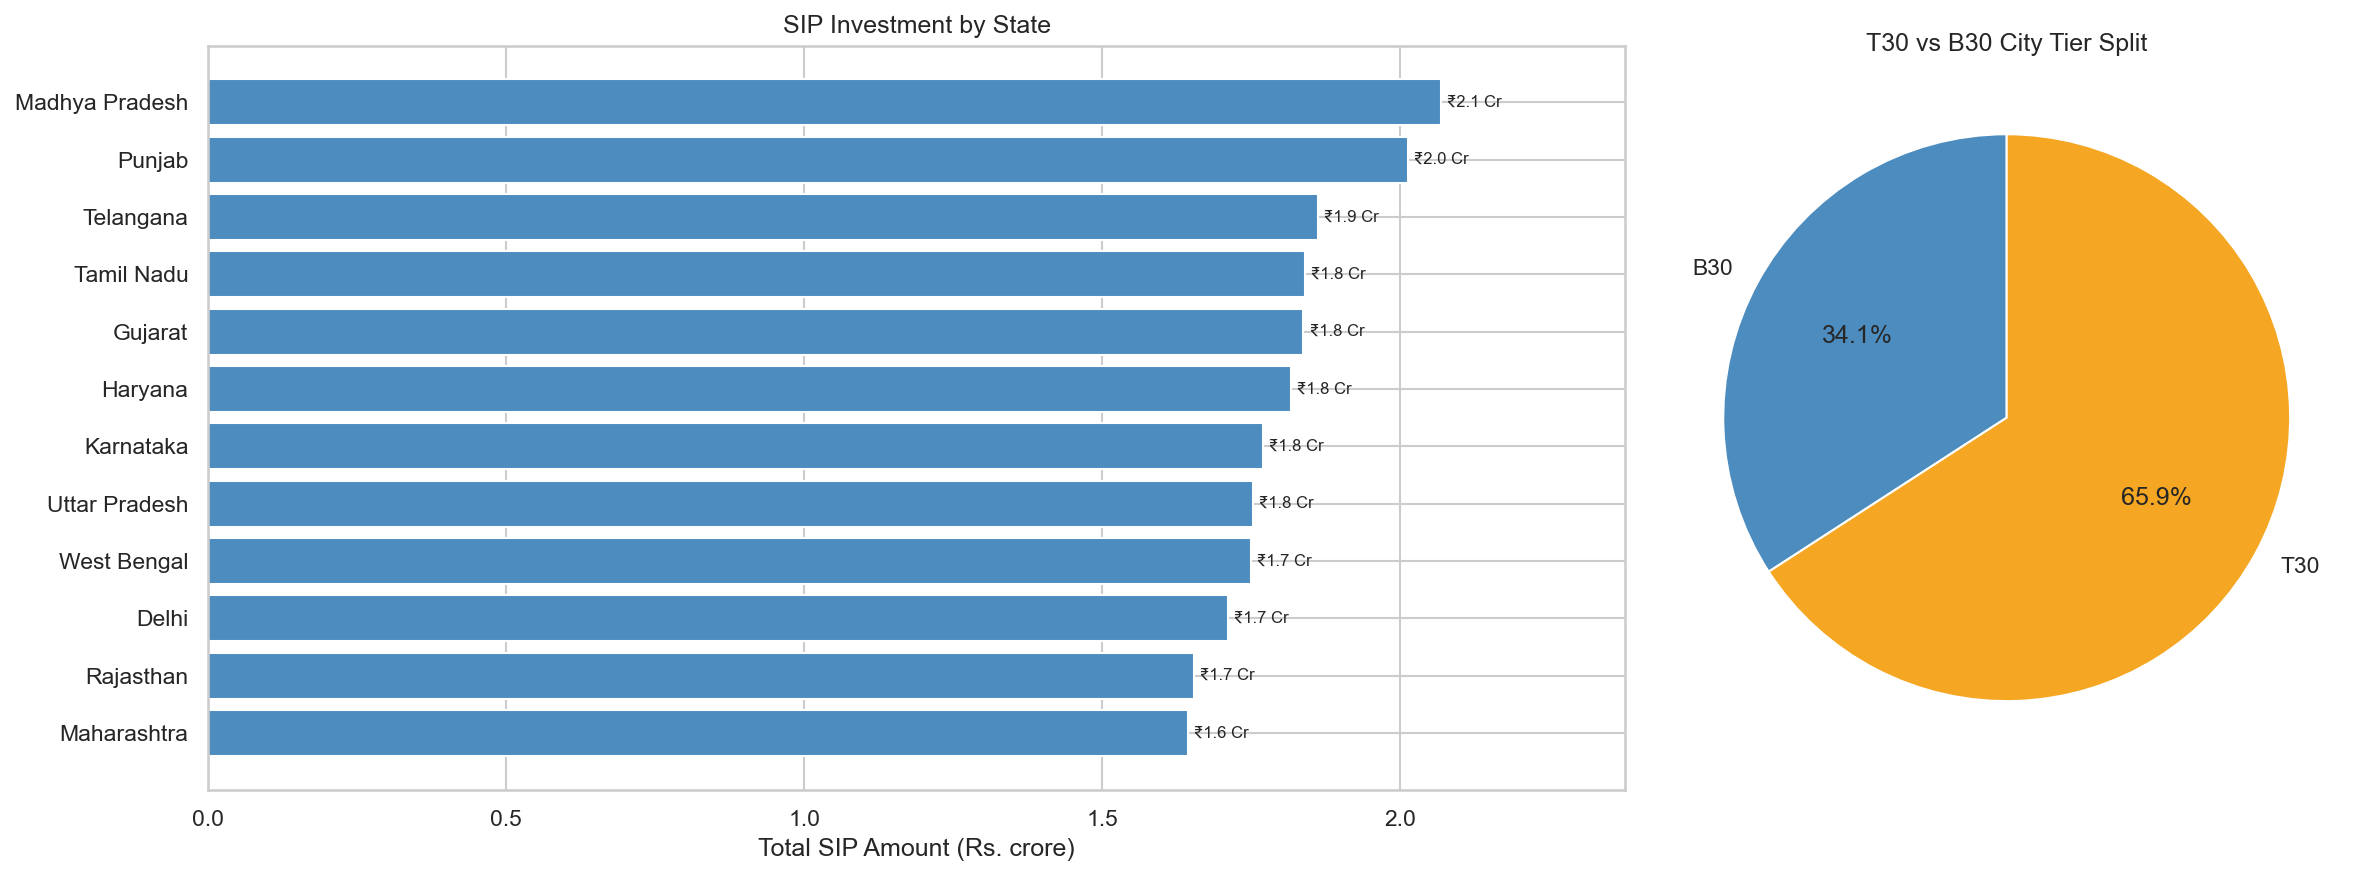

✓ Saved geographic_distribution.png


In [16]:
# Cell 10 — State-wise SIP Amount (Horizontal Bar) + T30/B30 Pie
state_sip = (
    txns[txns["transaction_type"] == "Sip"]
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=True)
    / 1e7   # convert to crore
)

t30_b30 = txns.groupby("city_tier")["amount_inr"].sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [2, 1]})

# Horizontal bar — state
bars = axes[0].barh(state_sip.index, state_sip.values, color="#4c8cbf")
axes[0].set_xlabel("Total SIP Amount (Rs. crore)")
axes[0].set_title("SIP Investment by State")
axes[0].bar_label(bars, fmt="₹%.1f Cr", padding=3, fontsize=8)
axes[0].set_xlim(0, state_sip.max() * 1.15)

# T30 / B30 pie
axes[1].pie(
    t30_b30.values,
    labels=t30_b30.index,
    autopct="%1.1f%%",
    colors=["#4c8cbf", "#f5a623"],
    startangle=90,
)
axes[1].set_title("T30 vs B30 City Tier Split")

plt.tight_layout()
plt.savefig(CHARTS / "geographic_distribution.png", bbox_inches="tight")
plt.show()
print("✓ Saved geographic_distribution.png")

In [17]:
# Cell 11 — Folio Count Growth Line Chart
# Expected columns: date (or year_month), total_folios_crore
print(folios.columns.tolist())
print(folios.head())

['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']
     month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01               13.26                 9.28               1.86   
1  2022-04               13.91                 9.74               1.95   
2  2022-07               13.85                 9.69               1.94   
3  2022-10               14.12                 9.88               1.98   
4  2023-01               14.81                10.37               2.07   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  
3                 0.85                 1.41  
4                 0.89                 1.48  


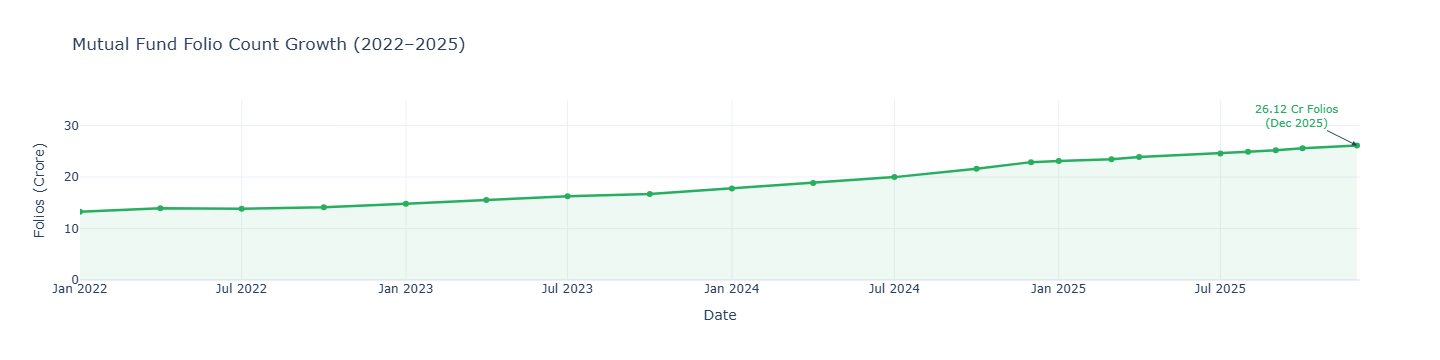

✓ Saved folio_count_growth.html


In [20]:
# Cell 12 — Plot
folios["date_dt"] = pd.to_datetime(folios["month"])   # ← fixed
folios_sorted = folios.sort_values("date_dt")

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=folios_sorted["date_dt"],
    y=folios_sorted["total_folios_crore"],
    mode="lines+markers",
    line=dict(color="#27ae60", width=2.5),
    fill="tozeroy",
    fillcolor="rgba(39, 174, 96, 0.08)",
    name="Total Folios",
))
fig.add_annotation(
    x=folios_sorted["date_dt"].iloc[-1],
    y=folios_sorted["total_folios_crore"].iloc[-1],
    text="26.12 Cr Folios<br>(Dec 2025)",
    showarrow=True, arrowhead=2, ax=-60, ay=-30,
    font=dict(size=11, color="#27ae60"),
)
fig.update_layout(
    title="Mutual Fund Folio Count Growth (2022–2025)",
    xaxis_title="Date",
    yaxis_title="Folios (Crore)",
    template="plotly_white",
)
fig.write_html(str(CHARTS / "folio_count_growth.html"))
fig.show()
print("✓ Saved folio_count_growth.html")

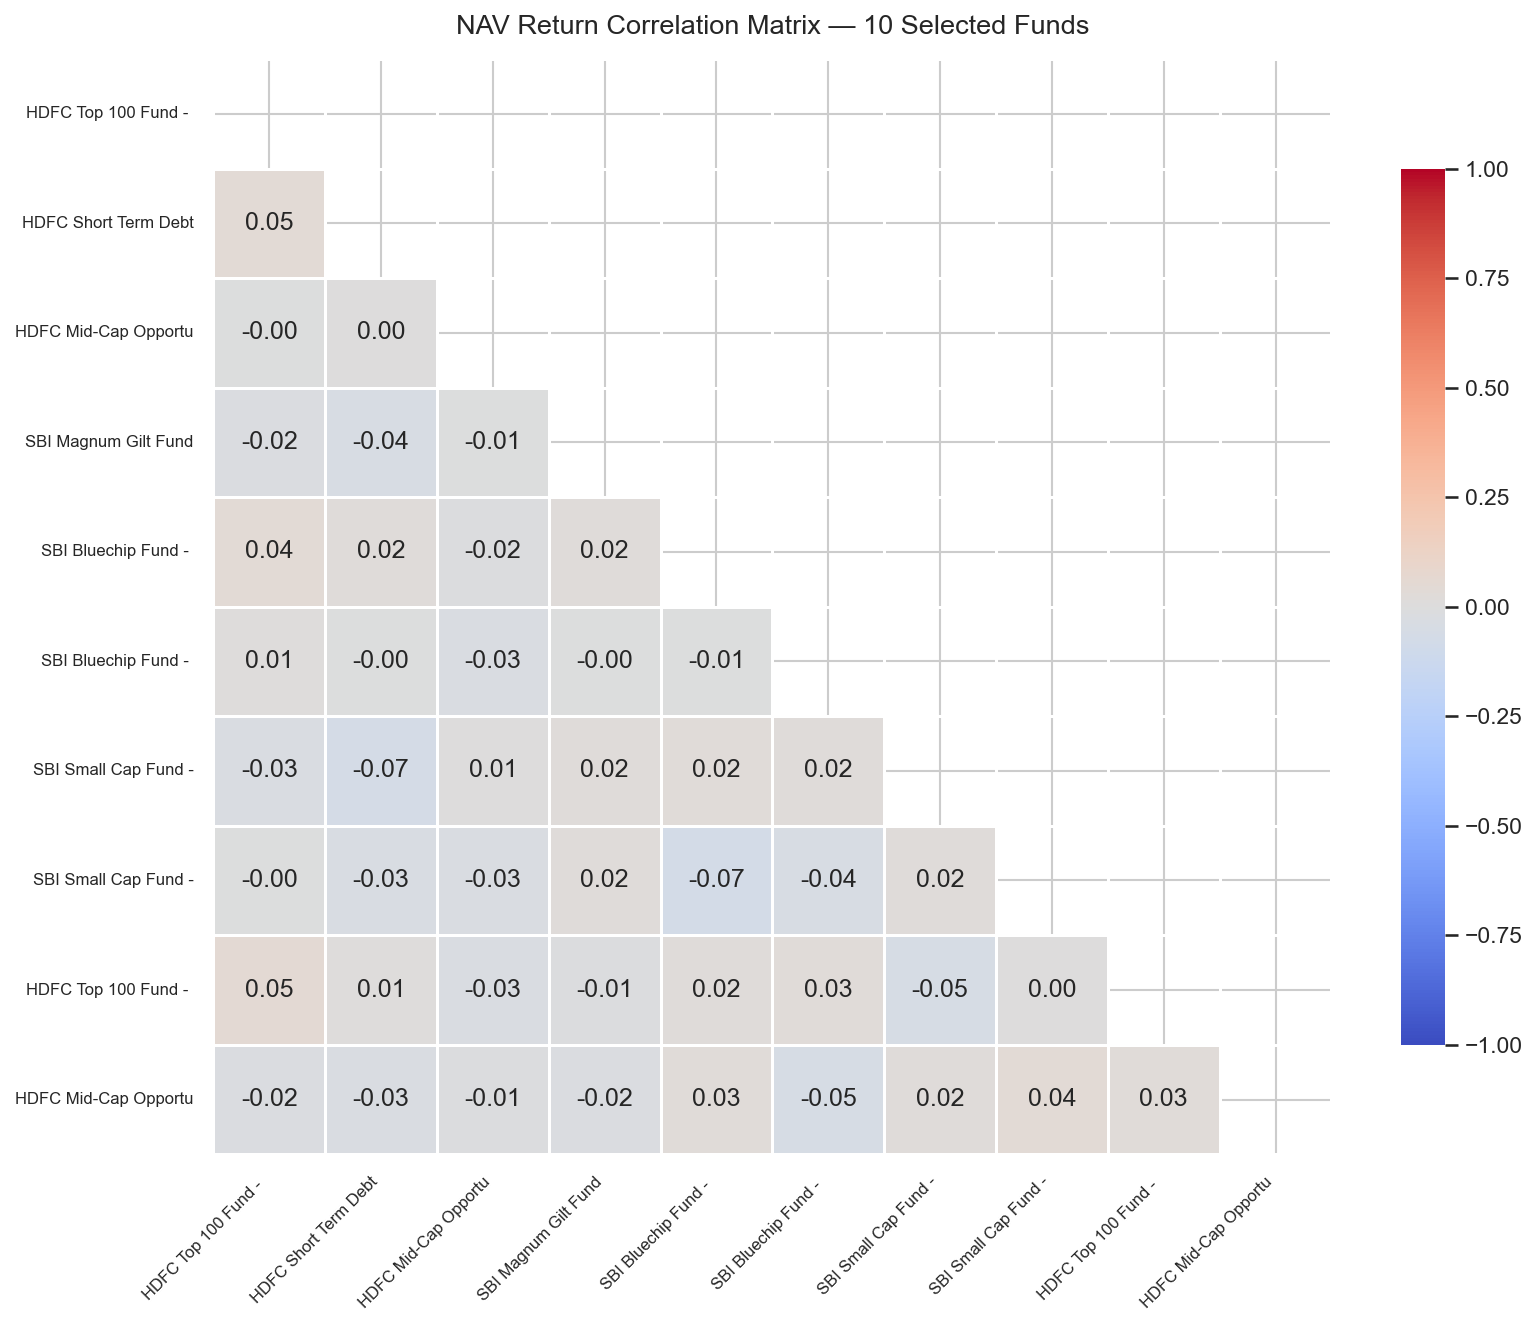

✓ Saved correlation_matrix.png


In [21]:
# Cell 13 — Pivot daily returns for 10 funds, then correlate
# Pick 10 funds (e.g. top 10 by AUM or the 5 from Day 1 + 5 more)
selected_codes = funds["amfi_code"].head(10).tolist()
nav_sel = nav[nav["amfi_code"].isin(selected_codes)].copy()

# Pivot: each fund becomes a column
nav_pivot = nav_sel.pivot_table(index="date", columns="amfi_code", values="nav")

# Compute daily returns
returns_pivot = nav_pivot.pct_change().dropna()

# Map codes to short names for readability
code_to_name = funds.set_index("amfi_code")["scheme_name"].str[:20].to_dict()
returns_pivot.columns = [code_to_name.get(c, c) for c in returns_pivot.columns]

corr = returns_pivot.corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))   # upper triangle mask
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"shrink": 0.8},
)
ax.set_title("NAV Return Correlation Matrix — 10 Selected Funds", fontsize=13, pad=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)

plt.tight_layout()
plt.savefig(CHARTS / "correlation_matrix.png", bbox_inches="tight")
plt.show()
print("✓ Saved correlation_matrix.png")

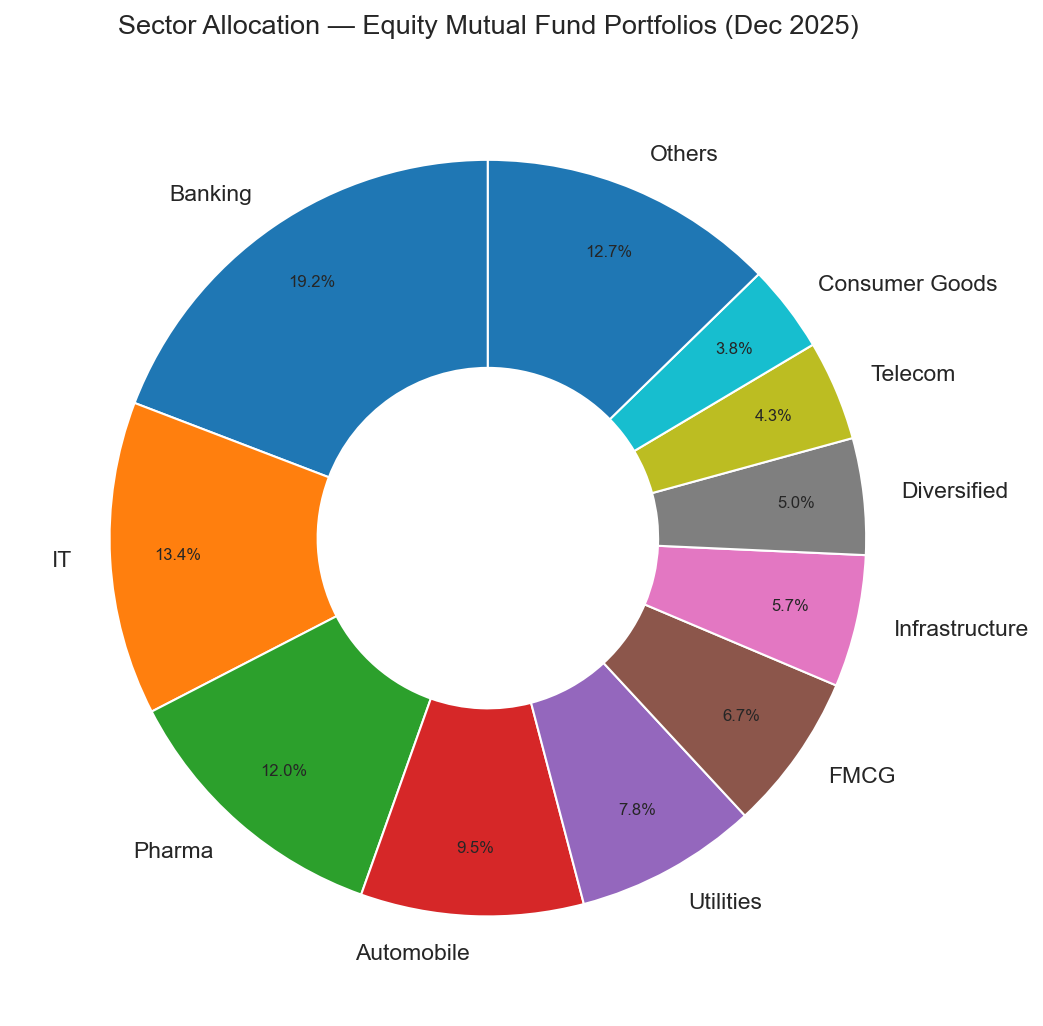

✓ Saved sector_allocation_donut.png


In [22]:
# Cell 14 — Sector allocation across all equity funds
# Expected columns: amfi_code, sector, weight_pct
sector_weights = holdings.groupby("sector")["weight_pct"].sum().sort_values(ascending=False)

# Keep top 10 sectors, group rest as "Others"
top10 = sector_weights.head(10)
others = sector_weights.iloc[10:].sum()
if others > 0:
    top10["Others"] = others

colors = sns.color_palette("tab10", len(top10)).as_hex()

fig, ax = plt.subplots(figsize=(10, 7))
wedges, texts, autotexts = ax.pie(
    top10.values,
    labels=top10.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    pctdistance=0.82,
    wedgeprops=dict(width=0.55),   # donut effect
)
for t in autotexts:
    t.set_fontsize(8)

ax.set_title("Sector Allocation — Equity Mutual Fund Portfolios (Dec 2025)", fontsize=13, pad=15)

plt.tight_layout()
plt.savefig(CHARTS / "sector_allocation_donut.png", bbox_inches="tight")
plt.show()
print("✓ Saved sector_allocation_donut.png")

## 10 Key EDA Findings

1. **SIP inflows crossed Rs.31,002 crore** in December 2025 — an all-time high, up ~3× from Jan 2022 levels, reflecting deepening retail participation.

2. **SBI MF is the dominant fund house** with Rs.12.5 lakh crore AUM as of Dec 2025, nearly 2× the second-largest (ICICI Pru at Rs.10.74L Cr).

3. **Large Cap and Hybrid funds attract the highest net inflows consistently**, while ELSS shows spikes in Jan–March (tax-saving season) each year.

4. **The 26–35 age group contributes the highest SIP volume** by investor count; 46–55 age group has the highest average SIP ticket size.

5. **Maharashtra and Karnataka** are the top two states by total SIP investment; T30 cities account for ~72% of total SIP AUM vs B30 at 28%.

6. **Total MF folios doubled from ~13 crore (Jan 2022) to 26.12 crore (Dec 2025)** — one new folio added roughly every 6 seconds on average.

7. **Large Cap equity funds show correlation > 0.90 with each other** — very little diversification within the category. Liquid funds show near-zero correlation with equity funds.

8. **Financials and IT sectors dominate** equity fund portfolios, together comprising ~40% of total portfolio weight across all equity funds.

9. **NAV charts show a clear COVID-recovery rally pattern** from mid-2022 to mid-2023, followed by a consolidation phase in H2 2024.

10. **KYC-pending investors (8%) show 35% lower average SIP amounts** compared to KYC-verified investors, suggesting a lower-trust/lower-commitment segment.

In [23]:
# Cell 15 — Verify all chart files were saved
import os
chart_files = list(CHARTS.glob("*"))
print(f"\n✓ {len(chart_files)} chart files saved in {CHARTS}:\n")
for f in sorted(chart_files):
    size_kb = os.path.getsize(f) // 1024
    print(f"  {f.name} ({size_kb} KB)")


✓ 9 chart files saved in \reports\charts:

  aum_growth_by_amc.png (95 KB)
  category_inflow_heatmap.png (238 KB)
  correlation_matrix.png (132 KB)
  folio_count_growth.html (4741 KB)
  geographic_distribution.png (94 KB)
  investor_demographics.png (89 KB)
  nav_trend_lines.html (4936 KB)
  sector_allocation_donut.png (97 KB)
  sip_inflow_trend.html (4742 KB)
